# Population Growth Prediction ( Sigmoid Fit )

## At this project , I want to use the non-linear regression algorithm with sigmoid-fit method to recognition pattern and predict future population growth

#### Loading the daataset .
#### This dataset formated CSV , includes information about 265 countries population from the 60s to the present .you can download this dataset from datahub.io . Source : https://datahub.io/core/population/_r/-/data/population.csv

## Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading the dataset

In [31]:
df = pd.read_csv('dataset/population.csv')
df

,Country Name,Country Code,Year,Value
0,Aruba,ABW,1960,54922
1,Aruba,ABW,1961,55578
2,Aruba,ABW,1962,56320
3,Aruba,ABW,1963,57002
4,Aruba,ABW,1964,57619
...,...,...,...,...
17190,Zimbabwe,ZWE,2020,15526888
17191,Zimbabwe,ZWE,2021,15797210
17192,Zimbabwe,ZWE,2022,16069056
17193,Zimbabwe,ZWE,2023,16340822


#### Getting some information about data from dataset

In [32]:
df.describe()

,Year,Value
count,17195.000000,1.719500e+04
mean,1992.030532,2.182379e+08
std,18.760828,7.142151e+08
min,1960.000000,2.715000e+03
25%,1976.000000,1.019463e+06
50%,1992.000000,6.790788e+06
75%,2008.000000,4.706578e+07
max,2024.000000,8.141809e+09


In [33]:
countries = df['Country Name'].unique()
print(f'The count of Countries {len(countries)}')
countries

The count of Countries 265


<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina',
 ...
       'Virgin Islands (U.S.)',                    'Viet Nam',
                     'Vanuatu',                       'World',
                       'Samoa',                      'Kosovo',
                 'Yemen, Rep.',                'South Africa',
                      'Zambia',                    'Zimbabwe']
Length: 265, dtype: str

### I want to working on Tajikistan data on this dataset so at the first stage , I will create a new DataFrame with only Tajikistan data

#### Searching for maches name

In [34]:
maches = [c for c in df['Country Name'].unique() if 'ajik' in c]
maches

['Tajikistan']

#### I found the maches name 'Tajikistan' . So now I must create with only 'Tajikistan' country name to continue

In [35]:
tj = df[df['Country Name'] == 'Tajikistan']
tj

,Country Name,Country Code,Year,Value
15115,Tajikistan,TJK,1960,2112131
15116,Tajikistan,TJK,1961,2181805
15117,Tajikistan,TJK,1962,2255026
15118,Tajikistan,TJK,1963,2331736
15119,Tajikistan,TJK,1964,2411260
...,...,...,...,...
15175,Tajikistan,TJK,2020,9749310
15176,Tajikistan,TJK,2021,9966908
15177,Tajikistan,TJK,2022,10182222
15178,Tajikistan,TJK,2023,10389799


### Now we have full 'Tajikistan' data . but this data isn't clean . so let's check the data and clean it

In [36]:
miss_val = tj.isna().sum().sum()
dup_val = tj.duplicated().sum()

print('Missing Values Count : ' , miss_val)
print('Duplicated Values Count : ' , dup_val)

Missing Values Count :  0
Duplicated Values Count :  0


### dataset dosn't have any Missing value or Duplicated value . So I want plot it to see data distribution and find Outliers

Text(0.5, 1.0, 'Population per Year')

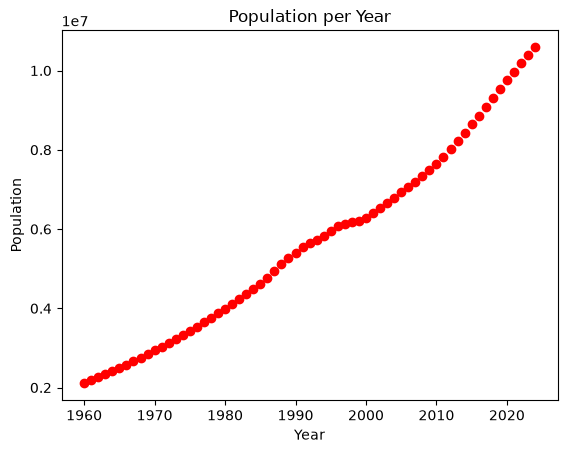

In [37]:
plt.scatter(tj.Year , tj.Value , color= 'red')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population per Year')

## I found two S Curve pattern at this plot . so I think it's a logistic function 
The formula for the logistic function is the following:

$$ \hat{Y} = \frac1{1+e^{\beta\_1(X-\beta\_2)}}$$

$\beta\_1$: Controls the curve's steepness,

$\beta\_2$: Slides the curve on the x-axis.


## Now let's create a model

In [38]:
def sigmoid(x , k , beta_1 , beta_2):
    y = k / (1 + np.exp(-beta_1 * (x - beta_2)))
    return y


#### Now we have Y that will return from sidmoid method . So I must now transform X to train/test split data 

In [56]:
train = tj.iloc[:int(len(tj) * 0.8)]
test = tj.iloc[int(len(tj) * 0.8):]

In [57]:
train_x = train['Year'].values.astype('int')
train_y = train['Value'].values.astype('int')

test_x = test['Year'].values.astype('int')
test_y = test['Value'].values.astype('int')

#### I created two set of data 80/20 for train/test . now let's look at a sample sigmoid line that might fit the data

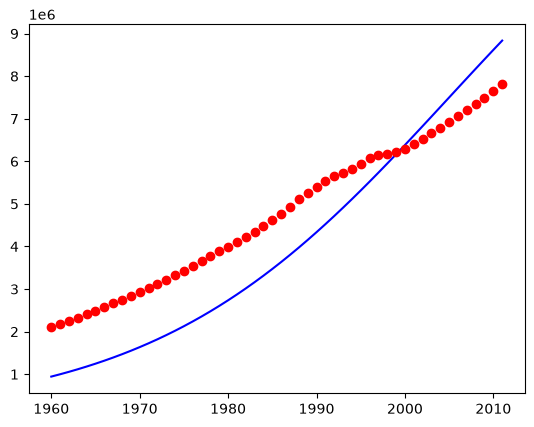

In [58]:
beta_1 = 0.06
beta_2 = 2005

# Logistic function
y_pred = sigmoid(train_x , 1 , beta_1 , beta_2)

plt.plot(train_x , y_pred * 15_000_000 , color='blue') # I use mutiplication becuse without it , we have binayr output (0 - 1)
plt.plot(train_x , train_y , 'ro')

### Now , our task , is find the better or if possible , find the best parameters for the model . Let's first , normalize x , y to break depency to multiplication

In [59]:
# Normalizing the data
normal_train_x = train_x / max(train_x)
normal_train_y = train_y / max(train_y)

## Now we have the nomalized data and I want to find the best parameters for the model

### For finding the best parameters for the model , I using 'Curve_fit' from 'SciPy' package

In [60]:
from scipy.optimize import curve_fit
popt , pcov = curve_fit(sigmoid , normal_train_x , normal_train_y)

# print the final parameters
print('beta_1 = %f , beta_2 = %f' % (popt[0] , popt[1]))

beta_1 = 1.327957 , beta_2 = 95.046149


/tmp/ipykernel_4418/4293715027.py:2: RuntimeWarning: overflow encountered in exp
  y = k / (1 + np.exp(-beta_1 * (x - beta_2)))


## Evaluation
### Now , we have the best possible parameters . Let's plot it .

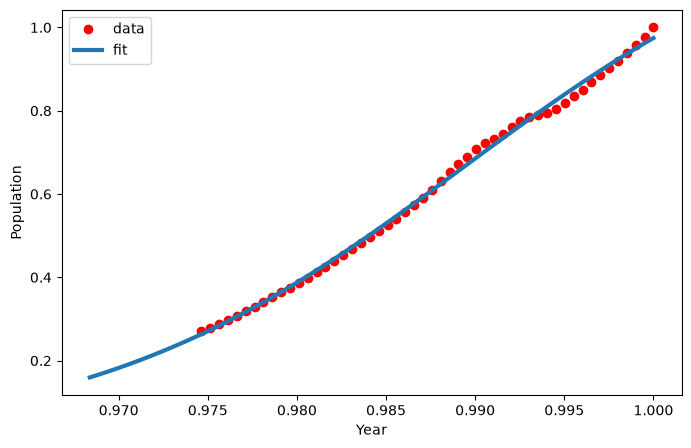

In [61]:
x = np.linspace(1960, 2024, 84)
x = x/max(x)
plt.figure(figsize=(8 , 5))
y = sigmoid(x, *popt)
plt.plot(normal_train_x, normal_train_y, 'ro', label='data')
plt.plot(x,y, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('Population')
plt.xlabel('Year')
plt.show()

### Evaluation with metrics

### First we must normalize test data

In [63]:
normal_test_x = test_x / max(test_x)
normal_test_y = test_y / max(test_y)

In [72]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

y_pred = sigmoid(normal_test_x , *popt)
y_pred = y_pred * max(test_y) # Unnormalization for Evaluation

mae = mean_absolute_error(test_y , y_pred)
mse = mean_squared_error(test_y , y_pred)
r2s = r2_score(test_y , y_pred)
rmse = np.sqrt(mse)

print('MAE : %.2f' %(mae))
print('MSE : %.2f' % mse)
print('RMSE : %.2f' % rmse)
print('R2 Score : %.2f' % r2s)

MAE : 274843.27
MSE : 105662496432.43
RMSE : 325057.68
R2 Score : 0.84
